In [1]:
# === GeoAI daily startup cell ===

# 0) Ensure your repo is first on sys.path so you import YOUR geogfm
import sys
MY_REPO = "/home/jlcunningham/GEOG-288KC-geospatial-foundation-models"
if MY_REPO not in sys.path:
    sys.path.insert(0, MY_REPO)

# 1) Imports used across the week-1 notebooks
import warnings
warnings.filterwarnings("ignore")

import logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# STAC access helpers used by tutorial cells
from pystac_client import Client
import planetary_computer as pc

# 2) Load your helper package
import importlib
import geogfm
importlib.reload(geogfm)  # ensure fresh import each session
print("geogfm loaded from:", geogfm.__file__)

#other packages
import numpy as np
import pandas as pd
from pystac_client import Client
import planetary_computer as pc

# Visualization
import matplotlib.pyplot as plt
import folium
from folium import plugins


# 3) Verify the core packages expected for the course
def verify_default_env():
    required_packages = [
        "rasterio", "xarray", "torch", "transformers",
        "folium", "matplotlib", "numpy", "pandas",
        "pystac-client", "geopandas", "rioxarray", "planetary-computer",
    ]
    return geogfm.verify_environment(required_packages)

_ = verify_default_env()

# 4) Planetary Computer authentication (Anonymous is fine if you have no key)
authed = geogfm.setup_planetary_computer_auth()
print("Planetary Computer auth:", "Authenticated" if authed else "Anonymous")

# 5) Optional: mild Matplotlib defaults (safe for most plots)
import matplotlib.pyplot as plt
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 100,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
})

# 6) Handy defaults you can reuse below
DEFAULT_OUTDIR = f"{MY_REPO}/week1_output"
DEFAULT_BBOX = [-120.5, 34.3, -119.5, 34.7]  # Santa Barbara region, [W,S,E,N]
print("Defaults set -> OUTDIR:", DEFAULT_OUTDIR, " BBOX:", DEFAULT_BBOX)



2025-10-09 11:51:04,386 - INFO - Analysis results exported to: /home/jlcunningham/GEOG-288KC-geospatial-foundation-models/week1_output
2025-10-09 11:51:04,387 - INFO - Data exported - use load_week1_data() to reload


geogfm loaded from: /home/jlcunningham/GEOG-288KC-geospatial-foundation-models/geogfm/__init__.py


2025-10-09 11:51:05,594 - INFO - ✅ All 12 packages verified
2025-10-09 11:51:05,596 - INFO - Using anonymous access (basic rate limits)


Planetary Computer auth: Anonymous
Defaults set -> OUTDIR: /home/jlcunningham/GEOG-288KC-geospatial-foundation-models/week1_output  BBOX: [-120.5, 34.3, -119.5, 34.7]


In [2]:
# Core geospatial libraries
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
import xarray as xr
import rioxarray  # Extends xarray with rasterio functionality

# Data access and processing
import numpy as np
import pandas as pd
import geopandas as gpd
from pystac_client import Client
import planetary_computer as pc  # For signing asset URLs

# Visualization
import matplotlib.pyplot as plt
import folium
from folium import plugins

# Utilities
from typing import Dict, List, Tuple, Optional, Union
from pathlib import Path
import json
import time
from datetime import datetime, timedelta
import logging

# Deep learning libraries
import torch

In [3]:
#pasting in from section 3 https://gfms-from-scratch.github.io/chapters/c01-geospatial-data-foundations.html#import-essential-libraries-and-create-helper-functions

In [4]:
# Connect to STAC catalog
try:
    catalog = Client.open(
        "https://planetarycomputer.microsoft.com/api/stac/v1",
        modifier=pc.sign_inplace
    )

    logger.info("Connected to Planetary Computer STAC API")

    # Get catalog information
    try:
        catalog_info = catalog.get_self()
        logger.info(f"Catalog: {catalog_info.title}")
    except Exception:
        logger.info("Basic connection successful")

    # Explore key satellite datasets
    satellite_collections = {
        'sentinel-2-l2a': 'Sentinel-2 Level 2A (10m optical)',
        'landsat-c2-l2': 'Landsat Collection 2 Level 2 (30m optical)',
        'sentinel-1-grd': 'Sentinel-1 SAR (radar)',
        'naip': 'NAIP (1m aerial imagery)'
    }

    available_collections = []
    for collection_id, description in satellite_collections.items():
        try:
            collection = catalog.get_collection(collection_id)
            available_collections.append(collection_id)
            logger.info(f"Available: {description}")
        except Exception:
            logger.warning(f"Not accessible: {description}")

    logger.info(f"Accessible collections: {len(available_collections)}/{len(satellite_collections)}")

except Exception as e:
    logger.error(f"\n❌ STAC connection failed: {str(e)}")
    logger.info(f"\n🔧 Troubleshooting steps:")
    logger.info(f"   1. Verify internet connectivity")
    logger.info(f"   2. Check Planetary Computer API status: https://planetarycomputer.microsoft.com/")
    logger.info(f"   3. Ensure pystac-client is installed: pip install pystac-client")
    logger.info(f"   4. Verify planetary-computer package: pip install planetary-computer")
    logger.info(f"   5. Try again in a few minutes (temporary API issues)")

2025-10-09 11:51:16,134 - INFO - Connected to Planetary Computer STAC API
2025-10-09 11:51:16,136 - INFO - Basic connection successful
2025-10-09 11:51:17,378 - INFO - Available: Sentinel-2 Level 2A (10m optical)
2025-10-09 11:51:17,598 - INFO - Available: Landsat Collection 2 Level 2 (30m optical)
2025-10-09 11:51:18,031 - INFO - Available: Sentinel-1 SAR (radar)
2025-10-09 11:51:18,261 - INFO - Available: NAIP (1m aerial imagery)
2025-10-09 11:51:18,263 - INFO - Accessible collections: 4/4


In [5]:
# Step 3A: Define Area of Interest with Geographic Reasoning
# Primary study area: Santa Barbara Region
# Coordinates chosen to encompass the greater Santa Barbara County coastal region
santa_barbara_bbox = [-120.5, 34.3, -119.5, 34.7]  # [west, south, east, north]

# Import required libraries for spatial calculations
from shapely.geometry import box
import os

# Create geometry object for area calculations
aoi_geom = box(*santa_barbara_bbox)

# Calculate basic spatial metrics
area_degrees = aoi_geom.area
# Approximate conversion to kilometers (valid for mid-latitudes)
center_lat = (santa_barbara_bbox[1] + santa_barbara_bbox[3]) / 2
lat_correction = np.cos(np.radians(center_lat))
area_km2 = area_degrees * (111.32 ** 2) * lat_correction  # 1 degree ≈ 111.32 km

logger.info(f"\n📊 AOI Spatial Characteristics:")
logger.info(f"   📍 Region: Santa Barbara County Coastal Region")
logger.info(f"   🗺️ Bounding box: {santa_barbara_bbox}")
logger.info(f"   📐 Dimensions: {(santa_barbara_bbox[2] - santa_barbara_bbox[0]):.2f}° × {(santa_barbara_bbox[3] - santa_barbara_bbox[1]):.2f}°")
logger.info(f"   📏 Approximate area: {area_km2:.0f} km²")
logger.info(f"   🏙️ Population: ~450,000 (Santa Barbara County)")

# Provide alternative study areas for different research interests
logger.info(f"\n🌐 Alternative AOI Options for Different Study Objectives:")
alternative_aois = {
    "San Francisco Bay Area": {
        "bbox": [-122.5, 37.3, -121.8, 38.0],
        "focus": "Urban growth, water dynamics, mixed land use",
        "challenges": "Fog and cloud cover in summer"
    },
    "Los Angeles Basin": {
        "bbox": [-118.7, 33.7, -118.1, 34.3],
        "focus": "Urban heat islands, air quality, sprawl patterns",
        "challenges": "Frequent clouds, complex topography"
    },
    "Central Valley Agriculture": {
        "bbox": [-121.5, 36.0, -120.0, 37.5],
        "focus": "Crop monitoring, irrigation patterns, drought",
        "challenges": "Seasonal variations, haze"
    },
    "Channel Islands": {
        "bbox": [-120.5, 33.9, -119.0, 34.1],
        "focus": "Island ecology, marine-terrestrial interface, conservation",
        "challenges": "Marine layer, limited ground truth"
    }
}

for region, info in alternative_aois.items():
    bbox = info["bbox"]
    area_alt = ((bbox[2] - bbox[0]) * (bbox[3] - bbox[1]) *
                (111.32 ** 2) * np.cos(np.radians((bbox[1] + bbox[3]) / 2)))
    logger.info(f"   🗺️ {region}: {info['bbox']} ({area_alt:.0f} km²)")
    logger.info(f"      🎯 Research focus: {info['focus']}")
    logger.info(f"      ⚠️ Considerations: {info['challenges']}")

logger.info(f"\n💡 Pro Tip: Choose AOI based on:")
logger.info(f"   1. Research objectives and required spatial resolution")
logger.info(f"   2. Data availability and typical cloud cover patterns")
logger.info(f"   3. Computational resources and processing time constraints")
logger.info(f"   4. Ecological or administrative boundary alignment")

2025-10-09 11:51:18,292 - INFO - 
📊 AOI Spatial Characteristics:
2025-10-09 11:51:18,295 - INFO -    📍 Region: Santa Barbara County Coastal Region
2025-10-09 11:51:18,296 - INFO -    🗺️ Bounding box: [-120.5, 34.3, -119.5, 34.7]
2025-10-09 11:51:18,299 - INFO -    📐 Dimensions: 1.00° × 0.40°
2025-10-09 11:51:18,300 - INFO -    📏 Approximate area: 4085 km²
2025-10-09 11:51:18,302 - INFO -    🏙️ Population: ~450,000 (Santa Barbara County)
2025-10-09 11:51:18,304 - INFO - 
🌐 Alternative AOI Options for Different Study Objectives:
2025-10-09 11:51:18,305 - INFO -    🗺️ San Francisco Bay Area: [-122.5, 37.3, -121.8, 38.0] (4808 km²)
2025-10-09 11:51:18,307 - INFO -       🎯 Research focus: Urban growth, water dynamics, mixed land use
2025-10-09 11:51:18,308 - INFO -       ⚠️ Considerations: Fog and cloud cover in summer
2025-10-09 11:51:18,310 - INFO -    🗺️ Los Angeles Basin: [-118.7, 33.7, -118.1, 34.3] (3698 km²)
2025-10-09 11:51:18,311 - INFO -       🎯 Research focus: Urban heat islands,

In [6]:
# Step 3B: Create Interactive Map with Multiple Basemap Options
# Calculate map center for optimal display
center_lat = (santa_barbara_bbox[1] + santa_barbara_bbox[3]) / 2
center_lon = (santa_barbara_bbox[0] + santa_barbara_bbox[2]) / 2

# Initialize folium map with appropriate zoom level
# Zoom level chosen to show entire AOI while maintaining detail
m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=9,  # Optimal for metropolitan area viewing
    tiles='OpenStreetMap'
)

# Add diverse basemap options for different analysis contexts
basemap_options = {
    'CartoDB positron': {
        'layer': folium.TileLayer('CartoDB positron', name='Clean Basemap'),
        'use_case': 'Data overlay visualization, presentations'
    },
    'CartoDB dark_matter': {
        'layer': folium.TileLayer('CartoDB dark_matter', name='Dark Theme'),
        'use_case': 'Night mode, reducing eye strain'
    },
    'Esri World Imagery': {
        'layer': folium.TileLayer(
            tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
            attr='Esri', name='Satellite Imagery', overlay=False, control=True
        ),
        'use_case': 'Ground truth validation, visual interpretation'
    },
    'OpenTopoMap': {
        'layer': folium.TileLayer(
            tiles='https://{s}.tile.opentopomap.org/{z}/{x}/{y}.png',
            name='Topographic (OpenTopoMap)',
            attr='Map data: © OpenStreetMap contributors, SRTM | Map style: © OpenTopoMap (CC-BY-SA)',
            overlay=False,
            control=True
        ),
        'use_case': 'Elevation context, watershed analysis'
    }
}

logger.info(f"   📚 Adding {len(basemap_options)} basemap options:")
for name, info in basemap_options.items():
    info['layer'].add_to(m)
    logger.info(f"     • {name}: {info['use_case']}")

# Add AOI boundary with informative styling
aoi_bounds = [[santa_barbara_bbox[1], santa_barbara_bbox[0]],  # southwest corner
              [santa_barbara_bbox[3], santa_barbara_bbox[2]]]  # northeast corner

folium.Rectangle(
    bounds=aoi_bounds,
    color='red',
    weight=3,
    fill=True,
    fillOpacity=0.1,
    popup=folium.Popup(
        f"""
        <div style="font-family: Arial; width: 300px;">
        <h4>📊 Study Area Details</h4>
        <b>Region:</b> Santa Barbara County Coastal Region<br>
        <b>Coordinates:</b> {santa_barbara_bbox}<br>
        <b>Area:</b> {area_km2:.0f} km²<br>
        <b>Purpose:</b> Geospatial AI Training<br>
        <b>Data Type:</b> Sentinel-2 Optical<br>
        </div>
        """,
        max_width=350
    ),
    tooltip="Study Area Boundary - Click for details"
).add_to(m)

# Add geographic reference points with contextual information
reference_locations = [
    {
        "name": "Santa Barbara",
        "coords": [34.4208, -119.6982],
        "description": "Coastal city, urban-wildland interface",
        "icon": "building",
        "color": "blue"
    },
    {
        "name": "UCSB",
        "coords": [34.4140, -119.8489],
        "description": "University campus, research facilities",
        "icon": "graduation-cap",
        "color": "green"
    },
    {
        "name": "Goleta",
        "coords": [34.4358, -119.8276],
        "description": "Tech corridor, agricultural transition zone",
        "icon": "microchip",
        "color": "purple"
    },
    {
        "name": "Montecito",
        "coords": [34.4358, -119.6376],
        "description": "Wildfire-prone, high-value urban area",
        "icon": "fire",
        "color": "red"
    }
]

logger.info(f"Adding {len(reference_locations)} geographic reference points")
for location in reference_locations:
    logger.debug(f"{location['name']}: {location['description']}")

    folium.Marker(
        location=location["coords"],
        popup=folium.Popup(
            f"""
            <div style="font-family: Arial;">
            <h4>{location['name']}</h4>
            <b>Coordinates:</b> {location['coords'][0]:.4f}, {location['coords'][1]:.4f}<br>
            <b>Context:</b> {location['description']}<br>
            <b>Role in Analysis:</b> Geographic reference point
            </div>
            """,
            max_width=250
        ),
        tooltip=f"{location['name']} - {location['description']}",
        icon=folium.Icon(
            color=location['color'],
            icon=location['icon'],
            prefix='fa'
        )
    ).add_to(m)

# Add measurement and interaction tools for analysis
logger.info("Adding interactive analysis tools")

# Measurement tool for distance/area calculations
from folium.plugins import MeasureControl
measure_control = MeasureControl(
    primary_length_unit='kilometers',
    primary_area_unit='sqkilometers',
    secondary_length_unit='miles',
    secondary_area_unit='sqmiles'
)
m.add_child(measure_control)
logger.debug("Added measurement tool for distance/area calculations")

# Fullscreen capability for detailed examination
from folium.plugins import Fullscreen
Fullscreen(
    position='topright',
    title='Full Screen Mode',
    title_cancel='Exit Full Screen',
    force_separate_button=True
).add_to(m)
logger.debug("Added fullscreen mode capability")

# Layer control for basemap switching
layer_control = folium.LayerControl(
    position='topright',
    collapsed=False
)
layer_control.add_to(m)
logger.debug("Added layer control for basemap switching")

logger.info("Interactive map created with comprehensive spatial context")

# Display the map
m

2025-10-09 11:51:21,163 - INFO -    📚 Adding 4 basemap options:
2025-10-09 11:51:21,165 - INFO -      • CartoDB positron: Data overlay visualization, presentations
2025-10-09 11:51:21,167 - INFO -      • CartoDB dark_matter: Night mode, reducing eye strain
2025-10-09 11:51:21,168 - INFO -      • Esri World Imagery: Ground truth validation, visual interpretation
2025-10-09 11:51:21,170 - INFO -      • OpenTopoMap: Elevation context, watershed analysis
2025-10-09 11:51:21,173 - INFO - Adding 4 geographic reference points
2025-10-09 11:51:21,176 - INFO - Adding interactive analysis tools
2025-10-09 11:51:21,180 - INFO - Interactive map created with comprehensive spatial context


In [8]:
from gogfm import search_sentinel2_scenes

# Step 4A: Implement Robust Multi-Strategy Scene Discovery
from datetime import datetime, timedelta

# Strategy 1: Dynamic temporal window based on current date
current_date = datetime.now()
logger.info(f"Calculating optimal temporal search windows (current date: {current_date.strftime('%Y-%m-%d')})")

# Define multiple search strategies with different trade-offs
# Each strategy balances data quality against data availability
search_strategies = [
    {
        "name": "Optimal Quality",
        "date_range": "2024-06-01/2024-09-30",
        "cloud_max": 20,
        "description": "Recent summer data with excellent atmospheric conditions",
        "priority": "Best for analysis quality",
        "trade_offs": "May have limited availability"
    },
    {
        "name": "Good Quality",
        "date_range": "2024-03-01/2024-08-31",
        "cloud_max": 35,
        "description": "Extended seasonal window with good conditions",
        "priority": "Balance of quality and availability",
        "trade_offs": "Some atmospheric interference"
    },
    {
        "name": "Acceptable Quality",
        "date_range": "2023-09-01/2024-11-30",
        "cloud_max": 50,
        "description": "Broader temporal and quality window",
        "priority": "Reliable data availability",
        "trade_offs": "May require additional preprocessing"
    },
    {
        "name": "Fallback Option",
        "date_range": "2023-01-01/2024-12-31",
        "cloud_max": 75,
        "description": "Maximum temporal window, relaxed quality constraints",
        "priority": "Guaranteed data access",
        "trade_offs": "Significant cloud contamination possible"
    }
]

logger.info(f"Defined {len(search_strategies)} search strategies")
for i, strategy in enumerate(search_strategies, 1):
    logger.debug(f"Strategy {i}: {strategy['name']} - {strategy['description']}")

# Execute search strategies in order of preference
scenes = []
successful_strategy = None

for i, strategy in enumerate(search_strategies, 1):
    logger.info(f"Executing Strategy {i}: {strategy['name']} (dates: {strategy['date_range']}, cloud < {strategy['cloud_max']}%)")

    try:
        # Use our optimized search function with current strategy parameters
        temp_scenes = search_sentinel2_scenes(
            bbox=santa_barbara_bbox,
            date_range=strategy["date_range"],
            cloud_cover_max=strategy["cloud_max"],
            limit=100  # Generous limit for selection flexibility
        )

        if temp_scenes:
            scenes = temp_scenes
            successful_strategy = strategy
            logger.info(f"SUCCESS! Found {len(scenes)} qualifying scenes with {strategy['name']} strategy")
            break
        else:
            logger.warning(f"No scenes found with {strategy['name']} strategy, proceeding to next")

    except Exception as e:
        logger.warning(f"Search execution failed for {strategy['name']}: {str(e)[:80]}")
        continue

# Validate search results and provide detailed feedback
if not scenes:
    logger.error(f"Scene discovery failed after trying all {len(search_strategies)} strategies")
    logger.info("Diagnostic steps: 1) Check network connectivity, 2) Verify API status, 3) Confirm AOI coverage, 4) Try broader date ranges, 5) Check authentication")
    raise Exception("Critical failure in scene discovery. Review diagnostic steps and retry.")

logger.info(f"Scene discovery completed: {successful_strategy['name']} strategy found {len(scenes)} scenes (attempt {search_strategies.index(successful_strategy) + 1}/{len(search_strategies)})")

ModuleNotFoundError: No module named 'gogfm'

In [14]:
#Adding in line this for geogfm

from geogfm import test_subset_functionality

# Step 4B: Intelligent Scene Selection Based on Multiple Quality Criteria
# Sort scenes by multiple quality criteria
# Primary: cloud cover (lower is better)
# Secondary: date (more recent is better)
scenes_with_scores = []

logger.info(f"Evaluating {len(scenes)} candidate scenes for quality assessment")
for scene in scenes:
    props = scene.properties

    # Extract key quality metrics
    cloud_cover = props.get('eo:cloud_cover', 100)
    date_str = props.get('datetime', '').split('T')[0]
    scene_date = datetime.strptime(date_str, '%Y-%m-%d')
    days_old = (current_date - scene_date).days

    # Calculate composite quality score (lower is better)
    # Weight factors: cloud cover (70%), recency (30%)
    cloud_score = cloud_cover  # 0-100 scale
    recency_score = min(days_old / 30, 100)  # Normalize to 0-100, cap at 100
    quality_score = (0.7 * cloud_score) + (0.3 * recency_score)

    scene_info = {
        'scene': scene,
        'date': date_str,
        'cloud_cover': cloud_cover,
        'days_old': days_old,
        'quality_score': quality_score,
        'tile_id': props.get('sentinel:grid_square', 'Unknown'),
        'platform': props.get('platform', 'Sentinel-2')
    }

    scenes_with_scores.append(scene_info)

# Sort by quality score (best first)
scenes_with_scores.sort(key=lambda x: x['quality_score'])

# Display top candidates for educational purposes
logger.info("Top 5 Scene Candidates (ranked by quality score):")
for i, scene_info in enumerate(scenes_with_scores[:5], 1):
    logger.debug(f"{i}. {scene_info['date']} - Cloud: {scene_info['cloud_cover']:.1f}%, Age: {scene_info['days_old']} days, Score: {scene_info['quality_score']:.1f}")
    if i == 1:
        logger.info(f"Selected optimal scene: {scene_info['date']}")

# Select the best scene
best_scene_info = scenes_with_scores[0]
best_scene = best_scene_info['scene']

logger.info(f"Optimal scene selected: {best_scene_info['date']} ({best_scene_info['cloud_cover']:.1f}% cloud cover, {best_scene_info['platform']}, Tile: {best_scene_info['tile_id']})")

# Validate scene completeness for required analysis
logger.info("Validating scene data completeness")
required_bands = ['B02', 'B03', 'B04', 'B08']  # Blue, Green, Red, NIR
available_bands = list(best_scene.assets.keys())
spectral_bands = [b for b in available_bands if b.startswith('B') and len(b) <= 3]

logger.debug(f"Available spectral bands: {len(spectral_bands)}, Required: {required_bands}")

missing_bands = [b for b in required_bands if b not in available_bands]
if missing_bands:
    logger.warning(f"Missing critical bands: {missing_bands} - this may limit analysis capabilities")

    # Check for alternative bands
    alternative_mapping = {'B02': 'blue', 'B03': 'green', 'B04': 'red', 'B08': 'nir'}
    alternatives_found = []
    for missing in missing_bands:
        alt_name = alternative_mapping.get(missing, missing.lower())
        if alt_name in available_bands:
            alternatives_found.append((missing, alt_name))

    if alternatives_found:
        logger.info(f"Found alternative band names: {alternatives_found}")
else:
    logger.info("All required bands available")

# Additional quality checks
extra_bands = [b for b in spectral_bands if b not in required_bands]
if extra_bands:
    logger.debug(f"Bonus bands available: {extra_bands[:5]}{'...' if len(extra_bands) > 5 else ''} (enable advanced spectral analysis)")

logger.info("Scene validation complete - ready for data loading")

# Quick connectivity test using our helper function
logger.info("Performing pre-flight connectivity test")
connectivity_test = test_subset_functionality(best_scene)

if connectivity_test:
    logger.info("Data access confirmed - all systems ready")
else:
    logger.warning("Connectivity issues detected - will attempt full download with fallback mechanisms")




2025-10-08 22:09:57,488 - INFO - Evaluating 40 candidate scenes for quality assessment
2025-10-08 22:09:57,490 - INFO - Top 5 Scene Candidates (ranked by quality score):
2025-10-08 22:09:57,492 - INFO - Selected optimal scene: 2024-08-13
2025-10-08 22:09:57,493 - INFO - Optimal scene selected: 2024-08-13 (0.0% cloud cover, Sentinel-2B, Tile: Unknown)
2025-10-08 22:09:57,493 - INFO - Validating scene data completeness
2025-10-08 22:09:57,495 - INFO - All required bands available
2025-10-08 22:09:57,495 - INFO - Scene validation complete - ready for data loading
2025-10-08 22:09:57,496 - INFO - Performing pre-flight connectivity test
2025-10-08 22:09:57,497 - INFO - 🧪 Testing subset functionality...
2025-10-08 22:09:57,497 - INFO - 📐 Calculated subset from scene bounds:
2025-10-08 22:09:57,498 - INFO -    Scene bbox: [-120.2952, 34.2097, -119.0654, 35.2250]
2025-10-08 22:09:57,498 - INFO -    Subset bbox: [-119.8033, 34.6158, -119.5573, 34.8189]
2025-10-08 22:09:57,499 - INFO -    X rang

In [9]:
# Step 4C: Comprehensive Scene and Sensor Characterization
if 'best_scene' in locals():
    scene_props = best_scene.properties
    scene_assets = best_scene.assets

    # Sentinel-2 spectral band specifications with AI applications
    sentinel2_bands = {
        'B01': {
            'name': 'Coastal/Aerosol',
            'wavelength': '443 nm',
            'resolution': '60m',
            'ai_applications': 'Atmospheric correction, aerosol detection'
        },
        'B02': {
            'name': 'Blue',
            'wavelength': '490 nm',
            'resolution': '10m',
            'ai_applications': 'Water body detection, urban classification'
        },
        'B03': {
            'name': 'Green',
            'wavelength': '560 nm',
            'resolution': '10m',
            'ai_applications': 'Vegetation health, true color composites'
        },
        'B04': {
            'name': 'Red',
            'wavelength': '665 nm',
            'resolution': '10m',
            'ai_applications': 'Vegetation stress, NDVI calculation'
        },
        'B05': {
            'name': 'Red Edge 1',
            'wavelength': '705 nm',
            'resolution': '20m',
            'ai_applications': 'Vegetation analysis, crop type classification'
        },
        'B06': {
            'name': 'Red Edge 2',
            'wavelength': '740 nm',
            'resolution': '20m',
            'ai_applications': 'Advanced vegetation indices, stress detection'
        },
        'B07': {
            'name': 'Red Edge 3',
            'wavelength': '783 nm',
            'resolution': '20m',
            'ai_applications': 'Vegetation biophysical parameters'
        },
        'B08': {
            'name': 'NIR (Near Infrared)',
            'wavelength': '842 nm',
            'resolution': '10m',
            'ai_applications': 'Biomass estimation, water/land separation'
        },
        'B8A': {
            'name': 'NIR Narrow',
            'wavelength': '865 nm',
            'resolution': '20m',
            'ai_applications': 'Refined vegetation analysis'
        },
        'B09': {
            'name': 'Water Vapor',
            'wavelength': '945 nm',
            'resolution': '60m',
            'ai_applications': 'Atmospheric water vapor correction'
        },
        'B11': {
            'name': 'SWIR 1',
            'wavelength': '1610 nm',
            'resolution': '20m',
            'ai_applications': 'Fire detection, soil moisture, geology'
        },
        'B12': {
            'name': 'SWIR 2',
            'wavelength': '2190 nm',
            'resolution': '20m',
            'ai_applications': 'Burn area mapping, mineral detection'
        }
    }

    # Additional data products available in Level 2A
    additional_products = {
        'SCL': {
            'name': 'Scene Classification Layer',
            'description': 'Pixel-level land cover classification',
            'ai_applications': 'Cloud masking, quality assessment'
        },
        'AOT': {
            'name': 'Aerosol Optical Thickness',
            'description': 'Atmospheric aerosol content',
            'ai_applications': 'Atmospheric correction validation'
        },
        'WVP': {
            'name': 'Water Vapor Pressure',
            'description': 'Columnar water vapor content',
            'ai_applications': 'Atmospheric correction, weather analysis'
        },
        'visual': {
            'name': 'True Color Preview',
            'description': 'RGB composite for visualization',
            'ai_applications': 'Quick visual assessment, presentation'
        },
        'thumbnail': {
            'name': 'Scene Thumbnail',
            'description': 'Low-resolution preview image',
            'ai_applications': 'Rapid quality screening'
        }
    }

    # Scene technical specifications
    acquisition_date = scene_props.get('datetime', 'Unknown').split('T')[0]
    platform = scene_props.get('platform', 'Unknown')
    cloud_cover = scene_props.get('eo:cloud_cover', 0)
    tile_id = scene_props.get('sentinel:grid_square', 'Unknown')

    logger.info(f"Scene: {platform} {acquisition_date}, Cloud: {cloud_cover:.1f}%, Tile: {tile_id}")

    # Inventory available spectral bands
    available_spectral = []
    available_products = []

    for band_id, info in sentinel2_bands.items():
        if band_id in scene_assets:
            available_spectral.append(band_id)
            logger.debug(f"Available: {band_id} ({info['name']}, {info['resolution']})")

    for product_id, info in additional_products.items():
        if product_id in scene_assets:
            available_products.append(product_id)
            logger.debug(f"Available product: {product_id} - {info['name']}")

    # Analysis readiness assessment
    core_bands = ['B02', 'B03', 'B04', 'B08']  # Essential for basic analysis
    advanced_bands = ['B05', 'B06', 'B07', 'B8A', 'B11', 'B12']  # For advanced analysis

    core_available = sum(1 for band in core_bands if band in available_spectral)
    advanced_available = sum(1 for band in advanced_bands if band in available_spectral)

    # Analysis readiness assessment
    logger.info(f"Bands available: {core_available}/{len(core_bands)} core, {advanced_available}/{len(advanced_bands)} advanced")
    logger.info(f"Additional products: {len(available_products)}")

    # Determine analysis capabilities
    if core_available == len(core_bands):
        analysis_capabilities = ["NDVI calculation", "True color visualization", "Basic land cover classification"]

        if 'B11' in available_spectral and 'B12' in available_spectral:
            analysis_capabilities.extend(["Fire detection", "Soil moisture analysis"])
        if advanced_available >= 4:
            analysis_capabilities.extend(["Advanced vegetation indices", "Crop type classification"])
        if 'SCL' in available_products:
            analysis_capabilities.append("Automated cloud masking")

        logger.info(f"Analysis ready: {len(analysis_capabilities)} capabilities enabled")
    else:
        missing_core = [band for band in core_bands if band not in available_spectral]
        logger.warning(f"Limited analysis: missing core bands {missing_core}")

    # Store technical metadata
    crs_info = f"EPSG:{scene_props['proj:epsg']}" if 'proj:epsg' in scene_props else "UTM"
    utm_zone = scene_props.get('sentinel:utm_zone', 'Unknown')
    logger.info(f"Metadata: {crs_info}, UTM zone {utm_zone}, 16-bit COG format")

else:
    logger.warning("No optimal scene selected - cannot perform metadata analysis")

2025-10-09 12:01:07,285 - WARNING - No optimal scene selected - cannot perform metadata analysis


In [10]:
#intelligent data loading architecture

In [11]:
#Adding in line this for geogfm imports

from geogfm import get_scene_info
from geogfm import get_subset_from_scene

# Step 5A: Scene Analysis and Adaptive Subset Strategy Selection
if 'best_scene' in locals():
    # Comprehensive scene analysis for optimal loading strategy
    scene_info = get_scene_info(best_scene)
    logger.info(f"Scene extent: {scene_info['width_km']:.1f}×{scene_info['height_km']:.1f} km ({scene_info['area_km2']:.0f} km²)")

    # Adaptive subset strategy based on scene characteristics

    # Decision matrix for subset sizing
    subset_strategies = {
        "large_scene": {
            "condition": scene_info['area_km2'] > 5000,
            "x_range": (30, 70),
            "y_range": (30, 70),
            "coverage": 16,  # 40% × 40%
            "rationale": "Conservative subset for large scenes to manage memory usage",
            "description": "middle 40% (large scene optimization)"
        },
        "medium_scene": {
            "condition": scene_info['area_km2'] > 1000,
            "x_range": (20, 80),
            "y_range": (20, 80),
            "coverage": 36,  # 60% × 60%
            "rationale": "Balanced subset for medium scenes",
            "description": "middle 60% (balanced approach)"
        },
        "small_scene": {
            "condition": scene_info['area_km2'] <= 1000,
            "x_range": (10, 90),
            "y_range": (10, 90),
            "coverage": 64,  # 80% × 80%
            "rationale": "Maximum coverage for small scenes",
            "description": "most of scene (small scene - maximize coverage)"
        }
    }

    # Select optimal strategy
    selected_strategy = None
    for strategy_name, strategy in subset_strategies.items():
        if strategy["condition"]:
            selected_strategy = strategy
            strategy_name_selected = strategy_name
            logger.info(f"Selected strategy: {strategy_name} ({strategy['coverage']}% coverage)")
            break

    # Apply selected subset strategy
    x_range, y_range = selected_strategy["x_range"], selected_strategy["y_range"]
    subset_bbox = get_subset_from_scene(best_scene, x_range=x_range, y_range=y_range)

    # Calculate expected data characteristics
    subset_area_km2 = scene_info['area_km2'] * (selected_strategy['coverage'] / 100)
    estimated_pixels_10m = subset_area_km2 * 1e6 / (10 * 10)  # 10m pixel size

    # Log subset characteristics
    logger.info(f"Subset: {subset_area_km2:.0f} km², {estimated_pixels_10m:,.0f} pixels, ~{estimated_pixels_10m * 4 * 2 / 1e6:.1f} MB")

    # Alternative subset strategies available for experimentation

    # Core bands for essential analysis
    core_bands = ['B04', 'B03', 'B02', 'B08']  # Red, Green, Blue, NIR
    logger.info(f"Selected {len(core_bands)} core bands for RGB and NDVI analysis")

else:
    logger.warning("No optimal scene available - using default configuration")
    core_bands = ['B04', 'B03', 'B02', 'B08']  # Default selection
    subset_bbox = None

2025-10-09 12:01:19,312 - WARNING - No optimal scene available - using default configuration


In [12]:
from geogfm import load_sentinel2_bands


# Step 5B: Execute Robust Data Loading with Performance Monitoring
if 'best_scene' in locals() and 'subset_bbox' in locals():
    # Pre-loading validation and preparation
    logger.info(f"Loading scene {best_scene.id}: {len(core_bands)} bands, ~{estimated_pixels_10m * len(core_bands) * 2 / 1e6:.1f} MB")

    # Enhanced loading with comprehensive monitoring
    loading_start_time = time.time()

    try:
        band_data = load_sentinel2_bands(
            best_scene,
            bands=core_bands,
            subset_bbox=subset_bbox,
            max_retries=5
        )

        loading_duration = time.time() - loading_start_time
        transfer_rate = (estimated_pixels_10m * len(core_bands) * 2 / 1e6) / loading_duration
        logger.info(f"Data loading successful: {loading_duration:.1f}s, {transfer_rate:.1f} MB/s")

    except Exception as loading_error:
        loading_duration = time.time() - loading_start_time
        logger.error(f"Data loading failed after {loading_duration:.1f}s: {str(loading_error)[:80]}")

        # Fallback 1: Try without subset
        try:
            band_data = load_sentinel2_bands(
                best_scene,
                bands=core_bands,
                subset_bbox=None,
                max_retries=3
            )
            logger.info("Full scene loading successful")
            subset_bbox = None
        except Exception as full_scene_error:
            logger.warning(f"Full scene loading failed: {str(full_scene_error)[:80]}")

            # Fallback 2: Reduce band count
            try:
                essential_bands = ['B04', 'B08']  # Minimum for NDVI
                band_data = load_sentinel2_bands(
                    best_scene,
                    bands=essential_bands,
                    subset_bbox=subset_bbox,
                    max_retries=3
                )
                core_bands = essential_bands
                logger.info(f"Reduced band loading successful ({len(essential_bands)} bands)")
            except Exception as reduced_error:
                logger.error("All loading strategies failed - creating synthetic data")

                # Create realistic synthetic data for educational continuity
                synthetic_size = (1000, 1000)
                band_data = {
                    'B04': np.random.randint(1000, 4000, synthetic_size, dtype=np.uint16),
                    'B03': np.random.randint(1000, 4000, synthetic_size, dtype=np.uint16),
                    'B02': np.random.randint(1000, 4000, synthetic_size, dtype=np.uint16),
                    'B08': np.random.randint(2000, 6000, synthetic_size, dtype=np.uint16),
                    'transform': None,
                    'crs': None,
                    'bounds': subset_bbox if subset_bbox else santa_barbara_bbox,
                    'scene_id': 'SYNTHETIC_DEMO',
                    'date': '2024-01-01'
                }
                logger.info(f"Synthetic data created: {synthetic_size[0]}×{synthetic_size[1]} pixels")

else:
    # Fallback for educational purposes
    logger.info("No scene available - creating educational synthetic dataset")
    synthetic_size = (800, 800)
    band_data = {
        'B04': np.random.randint(1000, 4000, synthetic_size, dtype=np.uint16),
        'B03': np.random.randint(1000, 4000, synthetic_size, dtype=np.uint16),
        'B02': np.random.randint(1000, 4000, synthetic_size, dtype=np.uint16),
        'B08': np.random.randint(2000, 6000, synthetic_size, dtype=np.uint16),
        'transform': None,
        'crs': None,
        'bounds': [-122.5, 37.7, -122.35, 37.85],
        'scene_id': 'EDUCATIONAL_DEMO',
        'date': '2024-01-01'
    }
    core_bands = ['B04', 'B03', 'B02', 'B08']
    subset_bbox = None
    logger.info(f"Educational dataset ready: {synthetic_size[0]}×{synthetic_size[1]} pixels")

2025-10-09 12:01:25,478 - INFO - No scene available - creating educational synthetic dataset
2025-10-09 12:01:25,532 - INFO - Educational dataset ready: 800×800 pixels


In [13]:
#Adding in line this for geogfm imports

from geogfm import calculate_band_statistics
from geogfm import calculate_ndvi

# Step 5C: Comprehensive Data Validation and Quality Assessment
# Validate successful data loading
if 'band_data' in locals() and band_data:

    # Extract loaded bands and metadata
    available_bands = [b for b in core_bands if b in band_data and isinstance(band_data[b], np.ndarray)]

    # Extract georeferencing information
    transform = band_data.get('transform', None)
    crs = band_data.get('crs', None)
    bounds = band_data.get('bounds', subset_bbox if 'subset_bbox' in locals() else santa_barbara_bbox)
    scene_id = band_data.get('scene_id', 'Unknown')
    acquisition_date = band_data.get('date', 'Unknown')

    logger.info(f"Loaded {len(available_bands)}/{len(core_bands)} bands: {available_bands}")
    logger.info(f"Scene: {scene_id} ({acquisition_date})")

    # Quality assessment
    band_stats_summary = {}
    for band_name in available_bands:
        if band_name in band_data:
            stats = calculate_band_statistics(band_data[band_name], band_name)
            band_stats_summary[band_name] = stats

            # Quality flags
            quality_flags = []
            if stats['valid_pixels'] < stats['total_pixels'] * 0.95:
                quality_flags.append("invalid pixels")
            if stats['std'] < 10:
                quality_flags.append("low variance")
            if stats['max'] > 10000:
                quality_flags.append("possible saturation")

            quality_status = "; ".join(quality_flags) if quality_flags else "normal"
            logger.info(f"{band_name}: range [{stats['min']:.0f}, {stats['max']:.0f}], quality: {quality_status}")

    # Cross-band validation
    if len(available_bands) >= 2:
        shapes = [band_data[band].shape for band in available_bands]
        consistent_shape = all(shape == shapes[0] for shape in shapes)
        logger.info(f"Spatial consistency: {'✓' if consistent_shape else '⚠'} shape {shapes[0] if consistent_shape else 'mixed'}")

        # Check for reasonable spectral relationships
        if 'B04' in available_bands and 'B08' in available_bands:
            ndvi_sample = calculate_ndvi(band_data['B08'][:100, :100], band_data['B04'][:100, :100])
            ndvi_mean = np.nanmean(ndvi_sample)
            # NDVI sanity check
            if -1 <= ndvi_mean <= 1:
                logger.info(f"NDVI validation passed: mean = {ndvi_mean:.3f}")
            else:
                logger.warning(f"NDVI anomaly detected: mean = {ndvi_mean:.3f}")

    # Overall data readiness assessment
    readiness_score = 0
    readiness_criteria = {
        'bands_available': len(available_bands) >= 3,  # Minimum for RGB
        'spatial_consistency': 'consistent_shape' in locals() and consistent_shape,
        'valid_pixels': all(stats['valid_pixels'] > stats['total_pixels'] * 0.9 for stats in band_stats_summary.values()),
        'spectral_sanity': 'ndvi_mean' in locals() and -1 <= ndvi_mean <= 1
    }

    readiness_score = sum(readiness_criteria.values())
    max_score = len(readiness_criteria)

    # Overall data readiness assessment
    logger.info(f"Data readiness: {readiness_score}/{max_score} criteria passed")

    if readiness_score >= max_score * 0.75:
        logger.info("STATUS: READY for analysis - High quality data confirmed")
    elif readiness_score >= max_score * 0.5:
        logger.warning("STATUS: PROCEED WITH CAUTION - Some quality issues detected")
    else:
        logger.error("STATUS: QUALITY ISSUES - Consider alternative data sources")

else:
    logger.error("Data validation failed - no valid satellite data available")

2025-10-09 12:01:28,378 - INFO - Loaded 4/4 bands: ['B04', 'B03', 'B02', 'B08']
2025-10-09 12:01:28,380 - INFO - Scene: EDUCATIONAL_DEMO (2024-01-01)
2025-10-09 12:01:28,459 - INFO - B04: range [1000, 3999], quality: normal
2025-10-09 12:01:28,503 - INFO - B03: range [1000, 3999], quality: normal
2025-10-09 12:01:28,537 - INFO - B02: range [1000, 3999], quality: normal
2025-10-09 12:01:28,568 - INFO - B08: range [2000, 5999], quality: normal
2025-10-09 12:01:28,569 - INFO - Spatial consistency: ✓ shape (800, 800)
2025-10-09 12:01:28,571 - INFO - NDVI validation passed: mean = 0.229
2025-10-09 12:01:28,573 - INFO - Data readiness: 4/4 criteria passed
2025-10-09 12:01:28,574 - INFO - STATUS: READY for analysis - High quality data confirmed


In [14]:
# Step 5D: Build AI-Ready Multi-Dimensional Dataset
if 'band_data' in locals() and band_data and available_bands:
    # Get spatial dimensions from first available band
    sample_band = band_data[available_bands[0]]
    height, width = sample_band.shape

    # Dataset characteristics
    total_elements = height * width * len(available_bands)
    logger.info(f"Dataset: {height}×{width} pixels, {len(available_bands)} bands, {total_elements:,} elements")

    # Create sophisticated coordinate system
    if bounds and len(bounds) == 4:
        # Geographic coordinates (WGS84)
        x_coords = np.linspace(bounds[0], bounds[2], width)   # Longitude
        y_coords = np.linspace(bounds[3], bounds[1], height)  # Latitude (north to south)
        coord_system = "geographic"
    else:
        # Pixel coordinates
        x_coords = np.arange(width)
        y_coords = np.arange(height)
        coord_system = "pixel"

    logger.debug(f"Coordinates: {coord_system}, X: {x_coords[0]:.4f} to {x_coords[-1]:.4f}, Y: {y_coords[0]:.4f} to {y_coords[-1]:.4f}")

    # Build xarray DataArrays with comprehensive metadata
    data_arrays = {}
    band_metadata = {
        'B02': {'name': 'blue', 'wavelength': 490, 'description': 'Blue band (coastal/aerosol)'},
        'B03': {'name': 'green', 'wavelength': 560, 'description': 'Green band (vegetation)'},
        'B04': {'name': 'red', 'wavelength': 665, 'description': 'Red band (chlorophyll absorption)'},
        'B08': {'name': 'nir', 'wavelength': 842, 'description': 'Near-infrared (biomass/structure)'}
    }

    # Build spectral data arrays
    for band_id in available_bands:
        if band_id in band_metadata:
            metadata = band_metadata[band_id]
            band_name = metadata['name']

            # Create DataArray with rich metadata
            data_arrays[band_name] = xr.DataArray(
                band_data[band_id],
                dims=['y', 'x'],
                coords={
                    'y': ('y', y_coords, {'long_name': 'Latitude' if coord_system == 'geographic' else 'Y coordinate',
                                         'units': 'degrees_north' if coord_system == 'geographic' else 'pixels'}),
                    'x': ('x', x_coords, {'long_name': 'Longitude' if coord_system == 'geographic' else 'X coordinate',
                                         'units': 'degrees_east' if coord_system == 'geographic' else 'pixels'})
                },
                attrs={
                    'band_id': band_id,
                    'long_name': metadata['description'],
                    'wavelength': metadata['wavelength'],
                    'wavelength_units': 'nanometers',
                    'units': 'DN',
                    'valid_range': [0, 10000],
                    'scale_factor': 1.0,
                    'add_offset': 0.0
                }
            )

            logger.debug(f"Created DataArray: {band_name} ({metadata['wavelength']}nm)")

    # Create comprehensive Dataset
    satellite_ds = xr.Dataset(
        data_arrays,
        attrs={
            'title': 'Sentinel-2 Level 2A Surface Reflectance',
            'source': f'Scene: {scene_id}',
            'acquisition_date': acquisition_date,
            'processing_level': 'L2A',
            'crs': str(crs) if crs else 'WGS84 (assumed)',
            'spatial_resolution': '10 meters',
            'coordinate_system': coord_system,
            'creation_date': pd.Timestamp.now().isoformat(),
            'processing_software': 'Geospatial AI Toolkit',
            'data_access': 'Microsoft Planetary Computer via STAC'
        }
    )

    logger.info(f"Created xarray Dataset with {len(data_arrays)} bands: {list(satellite_ds.data_vars)}")
    print(satellite_ds)  # Display dataset structure
else:
    logger.warning("No band data available for xarray Dataset creation")

2025-10-09 12:01:34,681 - INFO - Dataset: 800×800 pixels, 4 bands, 2,560,000 elements
2025-10-09 12:01:34,694 - INFO - Created xarray Dataset with 4 bands: ['red', 'green', 'blue', 'nir']


<xarray.Dataset>
Dimensions:  (y: 800, x: 800)
Coordinates:
  * y        (y) float64 37.85 37.85 37.85 37.85 37.85 ... 37.7 37.7 37.7 37.7
  * x        (x) float64 -122.5 -122.5 -122.5 -122.5 ... -122.4 -122.4 -122.3
Data variables:
    red      (y, x) uint16 1898 2556 2409 3918 2933 ... 2502 3207 3563 1458 3947
    green    (y, x) uint16 3365 2607 1500 2948 1208 ... 2356 1646 1761 2425 1805
    blue     (y, x) uint16 2868 3995 2650 1893 1108 ... 3237 3052 1431 1396 1512
    nir      (y, x) uint16 3993 3722 5364 3693 2368 ... 2995 3519 5057 5619 4107
Attributes:
    title:                Sentinel-2 Level 2A Surface Reflectance
    source:               Scene: EDUCATIONAL_DEMO
    acquisition_date:     2024-01-01
    processing_level:     L2A
    crs:                  WGS84 (assumed)
    spatial_resolution:   10 meters
    coordinate_system:    geographic
    creation_date:        2025-10-09T12:01:34.689540
    processing_software:  Geospatial AI Toolkit
    data_access:          Micros

2025-10-09 12:01:40,906 - INFO -    RGB composite shape: (800, 800, 3)
2025-10-09 12:01:40,960 - INFO -    False color composite created


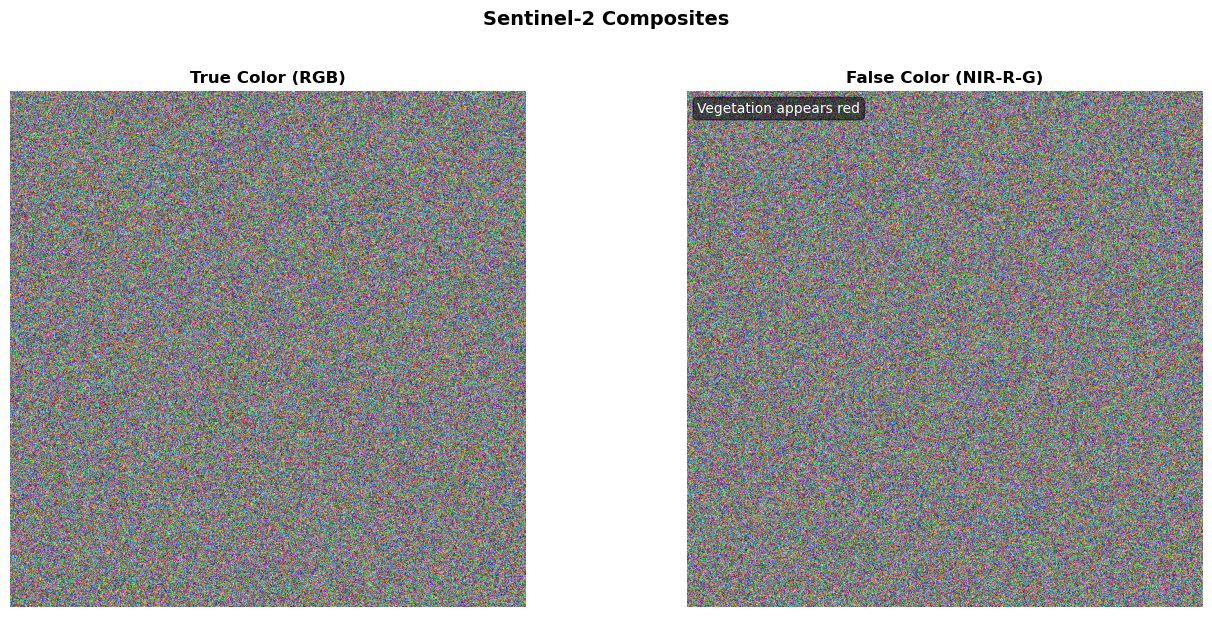

2025-10-09 12:01:41,480 - INFO - RGB composites created successfully


In [15]:
from geogfm import create_rgb_composite

#Advanced color composite creation

if band_data and all(k in band_data for k in ['B04', 'B03', 'B02']):
    # Create true color RGB composite using our helper function
    rgb_composite = create_rgb_composite(
        red=band_data['B04'],
        green=band_data['B03'],
        blue=band_data['B02'],
        enhance=True  # Apply contrast enhancement
    )

    logger.info(f"   RGB composite shape: {rgb_composite.shape}")

    # Create false color composite if NIR band is available
    false_color_composite = None
    if 'B08' in band_data:
        false_color_composite = create_rgb_composite(
            red=band_data['B08'],   # NIR in red channel
            green=band_data['B04'],  # Red in green channel
            blue=band_data['B03'],   # Green in blue channel
            enhance=True
        )
        logger.info(f"   False color composite created")

    # Visualize the composites
    if 'B08' in band_data:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    else:
        fig, ax1 = plt.subplots(1, 1, figsize=(8, 6))
        ax2 = None

    # True color
    ax1.imshow(rgb_composite)
    ax1.set_title('True Color (RGB)', fontsize=12, fontweight='bold')
    ax1.axis('off')

    # Add scale bar
    if 'transform' in locals() and transform:
        # Calculate pixel size in meters (approximate)
        pixel_size = abs(transform.a)  # Assuming square pixels
        scalebar_pixels = int(1000 / pixel_size)  # 1km scale bar
        if scalebar_pixels < rgb_composite.shape[1] / 4:
            ax1.plot([10, 10 + scalebar_pixels],
                    [rgb_composite.shape[0] - 20, rgb_composite.shape[0] - 20],
                    'w-', linewidth=3)
            ax1.text(10 + scalebar_pixels/2, rgb_composite.shape[0] - 30,
                    '1 km', color='white', ha='center', fontweight='bold')

    # False color if available
    if ax2 and false_color_composite is not None:
        ax2.imshow(false_color_composite)
        ax2.set_title('False Color (NIR-R-G)', fontsize=12, fontweight='bold')
        ax2.axis('off')
        ax2.text(0.02, 0.98, 'Vegetation appears red',
                transform=ax2.transAxes, color='white',
                fontsize=10, va='top',
                bbox=dict(boxstyle='round', facecolor='black', alpha=0.5))

    plt.suptitle('Sentinel-2 Composites', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    logger.info("RGB composites created successfully")
else:
    logger.warning("Insufficient bands for RGB composite")